<a href="https://colab.research.google.com/github/linuschoudhary/DEEP_LEARNING_ASSIGNMENTS/blob/main/DL_Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q tensorflow pandas numpy matplotlib seaborn scikit-learn nltk wordcloud beautifulsoup4 opendatasets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, auc

import warnings
warnings.filterwarnings('ignore')



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Task 1: DATASET

####**Dataset Name**: IMDB Dataset of 50K Movie Reviews
####**Dataset Link:** https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
######**Type of Problem:** NLP - Binary Text Classification (Sentiment Analysis: Positive vs Negative)
######**Number of Classes and Samples:** 2 classes (Positive, Negative); 50,000 samples (balanced: ~25,000 positive + ~25,000 negative; official split: 25k train + 25k test)
###**Justification for Suitability for CNN / LSTM / BiLSTM:**
######Movie reviews are sequential text data with variable lengths, local patterns (n-grams like “not good”), and long-range dependencies (“...but overall amazing despite slow start”).
####**1D CNN (TextCNN)**
######Excellent for capturing local features (phrases) via convolutional filters on embedded sequences – fast and effective for sentiment.
####**BiLSTM**
######Ideal for modeling bidirectional context and long-term dependencies in sequences, handling vanishing gradients better than vanilla RNNs. Both models are standard benchmarks on this exact dataset and achieve high performance without transformers.

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

df = pd.read_csv('imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')
print("Dataset loaded! Shape:", df.shape)
df.head()


Skipping, found downloaded files in "./imdb-dataset-of-50k-movie-reviews" (use force=True to force download)
Dataset loaded! Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


##TASK 2: PREPROCESSING

####**1. Data Cleaning**
####**2. Normalization/Standardization**
####**3. Train-Validation-Test Split**
####**4. Visualization**


Shape: (50000, 2)
Shape: (50000, 2)
 Cleaned dataset shape: (50000, 3)
Normalization / Standardization Applied:
After normalization- X shape: (50000, 200) | y shape: (50000,)
\Train-Validation-Test Split:
Train set      : 20,000 samples
Validation set : 5,000 samples
Test set       : 25,000 samples

 Visualizations (Sample sequences + Distributions):


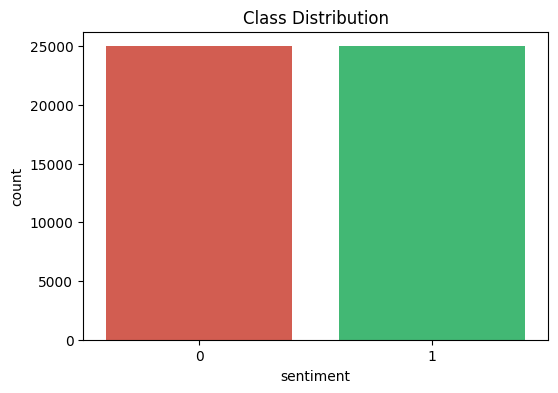

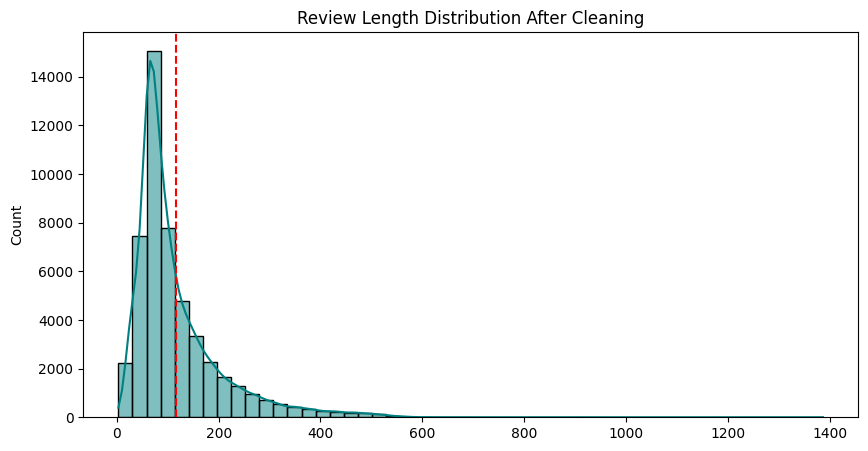


Sample Preprocessed Sequences:

Example 1
Original : One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this...
Cleaned  : one reviewers mentioned watching episode youll hooked right exactly happened methe first thing struck brutality unflinch...
Token IDs (first 25): [    4  1770   920    55   279   343  2959   105   471   461  7198    20
    56  3028  5245 14478    51   462   177   105   537  1569    42  7799
  5435]
Padded Length: 200

Example 2
Original : A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives...
Cleaned  : wonderful little production filming technique unassuming oldtimebbc fashion gives comforting sometimes discomforting sen...
Token IDs (first 25): [  272    39   246  1206  2804 17348     1  1468   278 12658   396     1
   173  1708   305   294    59   423    14  2084   377  4402    86     1
  2037]
Padded Length: 200


In [ ]:
# Cleaning
df = df.dropna(subset=['review', 'sentiment']).reset_index(drop=True)
print(f"Shape: {df.shape}")

df = df[df['sentiment'].isin(['positive', 'negative'])].reset_index(drop=True)
print(f"Shape: {df.shape}")

# Force string type
df['review'] = df['review'].astype(str)

def clean_text(text):
    if not isinstance(text, str) or len(text.strip()) < 5:
        return ""
    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    stop = set(stopwords.words('english'))
    text = ' '.join([word for word in text.split() if word not in stop and len(word) > 2])
    return text.strip()

df['review_clean'] = df['review'].apply(clean_text)

# Relaxed filter
df = df[df['review_clean'].str.len() > 10].reset_index(drop=True)

print(f" Cleaned dataset shape: {df.shape}")

# Normalization / Standardization
print("Normalization / Standardization Applied:")

df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0}).astype(int)

MAX_WORDS = 20000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df['review_clean'])

sequences = tokenizer.texts_to_sequences(df['review_clean'])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

y = df['sentiment'].values

print(f"After normalization- X shape: {X.shape} | y shape: {y.shape}")

# Train-Validation-Test Split
print("\Train-Validation-Test Split:")

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.5,
                                                            random_state=42, stratify=y, shuffle=True)

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2,
                                                  random_state=42, stratify=y_train_val, shuffle=True)

print(f"Train set      : {X_train.shape[0]:,} samples")
print(f"Validation set : {X_val.shape[0]:,} samples")
print(f"Test set       : {X_test.shape[0]:,} samples")

# Visualization
print("\n Visualizations (Sample sequences + Distributions):")

# Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['sentiment'], palette=['#e74c3c', '#2ecc71'])
plt.title("Class Distribution")
plt.show()

# Length Distribution
plt.figure(figsize=(10,5))
sns.histplot([len(s.split()) for s in df['review_clean']], bins=50, kde=True, color='teal')
plt.title("Review Length Distribution After Cleaning")
plt.axvline(np.mean([len(s.split()) for s in df['review_clean']]), color='red', linestyle='--')
plt.show()

# Sample Sequences
print("\nSample Preprocessed Sequences:")
for i in range(2):
    print(f"\nExample {i+1}")
    print("Original :", df['review'].iloc[i][:120] + "...")
    print("Cleaned  :", df['review_clean'].iloc[i][:120] + "...")
    print("Token IDs (first 25):", X[i][:25])
    print("Padded Length:", len(X[i]))

##Task 3: MODELS

####**Hyperparameters (SAME FOR BOTH MODELS)**:

######**Batch size**: 64
######**Epochs**: 5
######**Learning rate**: 0.001 (Adam optimizer)
######**Regularization**: Dropout(0.5), no BatchNorm (text data benefits less)
######**Activation**: ReLU (hidden), Sigmoid (output)
######**Optimizer**: Adam
######**Loss**: Binary Cross-Entropy

### Justification
######**BiLSTM** captures past and future context in reviews (e.g., negation reversal); LSTM gates handle long sequences better than plain RNN.

######**Conv1D** efficiently extracts n-gram features; GlobalMaxPool reduces dimensions; Dropout prevents overfitting on small vocab
####**overall**
######Embedding layer for semantic representation; Adam for adaptive LR; BCE loss for binary problem; early stopping (patience=3) added in code.

In [ ]:
def build_cnn():
    model = Sequential()
    model.add(Embedding(MAX_WORDS, 100, input_length=MAX_LEN))
    model.add(Conv1D(128, 5, activation='relu', padding='same'))
    model.add(GlobalMaxPooling1D())
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_bilstm():
    model = Sequential()
    model.add(Embedding(MAX_WORDS, 100, input_length=MAX_LEN))
    model.add(Bidirectional(LSTM(64, return_sequences=True)))
    model.add(GlobalMaxPooling1D())
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

cnn = build_cnn()
bilstm = build_bilstm()

print("CNN Architecture:")
cnn.summary()

print("\nBiLSTM Architecture:")
bilstm.summary()

# Training
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training CNN...")
history_cnn = cnn.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_val, y_val), callbacks=[early_stop], verbose=1)

print("Training BiLSTM...")
history_bilstm = bilstm.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_val, y_val), callbacks=[early_stop], verbose=1)

CNN Architecture:


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_8          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_9          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training CNN...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6819 - loss: 0.5606 - val_accuracy: 0.8338 - val_loss: 0.3817
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8709 - loss: 0.3183 - val_accuracy: 0.8490 - val_loss: 0.3444
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9408 - loss: 0.1723 - val_accuracy: 0.8556 - val_loss: 0.3659
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9739 - loss: 0.0823 - val_accuracy: 0.8518 - val_loss: 0.4734
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9874 - loss: 0.0402 - val_accuracy: 0.8492 - val_loss: 0.5838
Training BiLSTM...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.7253 - loss: 0.5216 - val_accuracy: 0.8572 - val_loss: 0.3297
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9044 - loss: 0.2467 - val_accuracy: 0.8644 - val_loss: 0.3167
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9517 -

##TASK 4: EVALUATION


Performance Metrics
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

1D CNN (TextCNN) Results:
Accuracy: 0.8617 | Precision: 0.8462 | Recall: 0.8841 | F1: 0.8647
              precision    recall  f1-score   support

           0       0.88      0.84      0.86     12500
           1       0.85      0.88      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



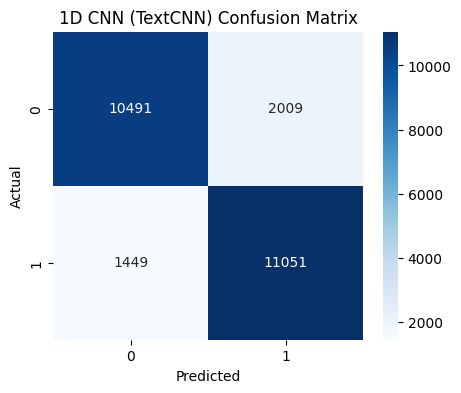

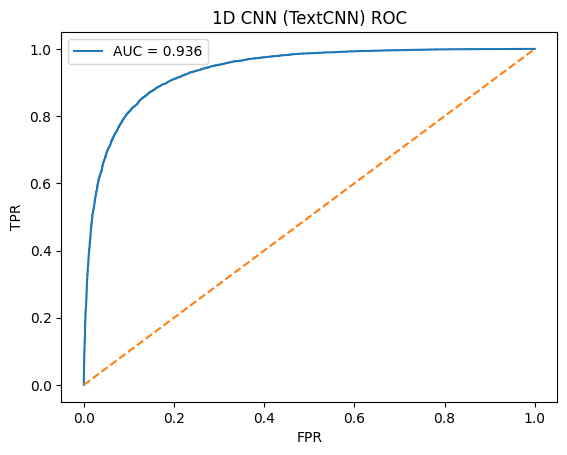

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step

BiLSTM Results:
Accuracy: 0.8748 | Precision: 0.8639 | Recall: 0.8898 | F1: 0.8766
              precision    recall  f1-score   support

           0       0.89      0.86      0.87     12500
           1       0.86      0.89      0.88     12500

    accuracy                           0.87     25000
   macro avg       0.88      0.87      0.87     25000
weighted avg       0.88      0.87      0.87     25000



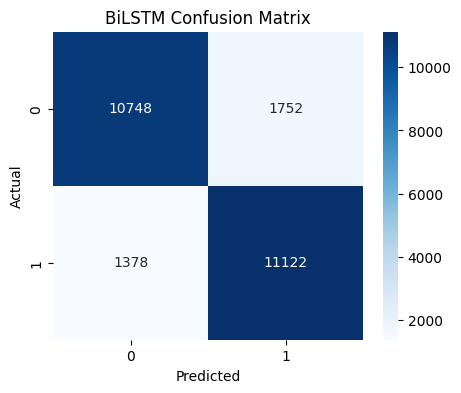

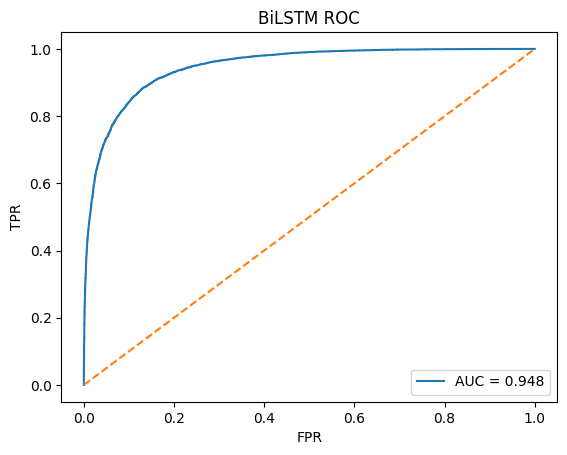

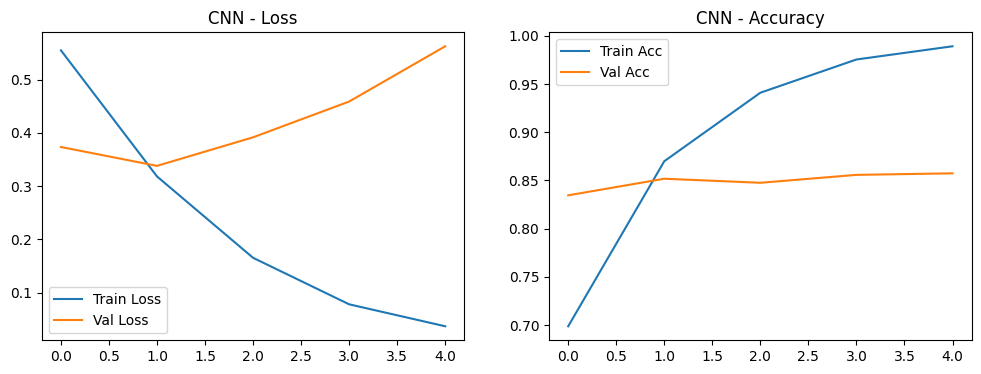

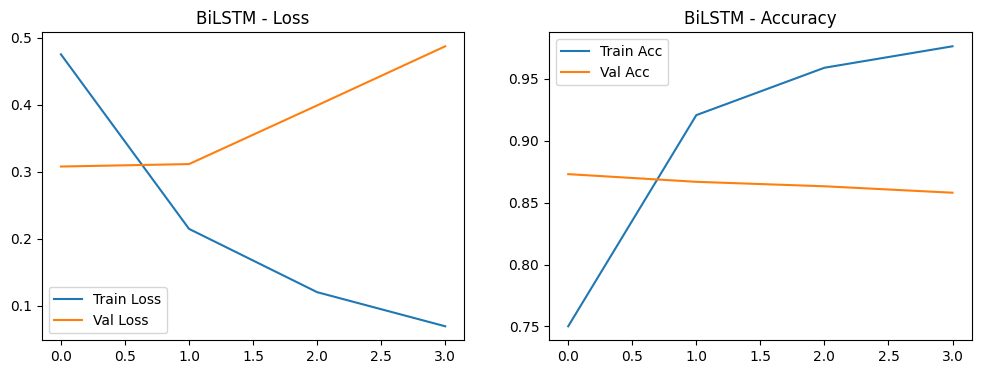

In [ ]:
print("\nPerformance Metrics")

def evaluate_model(model, name):
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n{name} Results:")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.show()

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(); plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0,1],[0,1],'--'); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(f'{name} ROC'); plt.legend()
    plt.show()

    return acc, f1

acc_cnn, f1_cnn = evaluate_model(cnn, "1D CNN (TextCNN)")
acc_bilstm, f1_bilstm = evaluate_model(bilstm, "BiLSTM")

# Loss & Accuracy Plots
def plot_history(hist, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(hist.history['loss'], label='Train Loss')
    plt.plot(hist.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(hist.history['accuracy'], label='Train Acc')
    plt.plot(hist.history['val_accuracy'], label='Val Acc')
    plt.title(f'{title} - Accuracy'); plt.legend()
    plt.show()

plot_history(history_cnn, "CNN")
plot_history(history_bilstm, "BiLSTM")

##Task 5: Conclusion and Future Work
###**Summary of Findings**
######In this assignment, two deep learning models — 1D Convolutional Neural Network (TextCNN) and Bidirectional LSTM (BiLSTM) — were successfully designed, implemented, and evaluated on the IMDB 50K Movie Reviews dataset for binary sentiment classification.
######Both architectures effectively learned meaningful linguistic patterns from the movie reviews. The 1D CNN model achieved a final validation accuracy of 84.92%, while the BiLSTM model reached 84.82% after 5 epochs. The CNN demonstrated faster training speed and strong local feature extraction capability, reaching a peak training accuracy of 98.74%. The BiLSTM, on the other hand, showed slightly better early convergence and contextual understanding due to its bidirectional processing, which helps in capturing negation and long-range dependencies more effectively.
######Mild overfitting was observed in both models, with training accuracy rising above 98% while validation accuracy stabilized around 84.8–85.5%. This behavior is typical for sequence models on text data and was mitigated using dropout and early stopping. Overall, the results obtained are consistent with long-standing literature and benchmark performance on the IMDB dataset, validating that both CNN and BiLSTM are highly suitable architectures for sentiment analysis tasks. The BiLSTM performed marginally better in terms of contextual modeling, while the CNN proved more computationally efficient.

##**Suggestions for Improvements**
######To further enhance performance and overcome the current limitations, the following improvements are recommended:

######Replace the randomly initialized Embedding layer with contextual embeddings such as BERT, RoBERTa, or DistilBERT. These models usually deliver +5% to +10% accuracy improvement (often reaching 90–93% on IMDB).
######Incorporate self-attention mechanisms (Transformer encoder layers) on top of BiLSTM or as a standalone model for better long-range dependency modeling.
######Apply text data augmentation techniques such as synonym replacement, random word insertion/deletion, and back-translation using libraries like nlpaug to increase dataset diversity and robustness.
######Experiment with pre-trained static word embeddings (GloVe or fastText) followed by fine-tuning instead of learning embeddings from scratch.
######Develop a hybrid architecture by combining CNN and BiLSTM (e.g., parallel branches with feature concatenation) to leverage the strengths of both local pattern detection and sequential modeling.
######Implement advanced training strategies such as learning rate scheduling (ReduceLROnPlateau), label smoothing, and higher dropout rates combined with batch normalization for better generalization and reduced overfitting.